# Matrix-Making Notebook

The purpose of this notebook is to create matrix-like figures that summarize accuracy of the model across various experiments run in climate_experiments.ipynb.

### Imports and File Stitching

In [38]:
# General Imports
import pandas as pd
import numpy as np
import os
import sys
import glob
import seaborn as sns

# Combinations
from itertools import combinations

# Plotting
import matplotlib.pyplot as plt

# ----File Stitching----
# If in climate_experiments folder, cd back to MamalakisResearch folder
if os.path.basename(os.getcwd()) == "climate_experiments":
    os.chdir('..')
# If a file is in /data_prep_viz/prep/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), '..', 'data_prep_viz/prep'))

### Read Files

In [39]:
# Read all csv files in climate_experiments folder
path = os.getcwd() + '/climate_experiments/'
csvs = glob.glob(os.path.join(path, "*sk.csv"))
summaries = []
for csv in csvs:
    df = pd.read_csv(csv)
    summaries.append(df)
summaries

[   scenario  early_yr  late_yr  mean_pred  accuracy
 0    ssp119      2015     2025   0.470245      0.82
 1    ssp119      2015     2035   0.410600      0.84
 2    ssp119      2015     2045   0.466150      0.98
 3    ssp119      2015     2055   0.430172      0.90
 4    ssp119      2015     2065   0.532195      0.92
 5    ssp119      2015     2075   0.595301      0.90
 6    ssp119      2015     2085   0.489195      0.68
 7    ssp119      2025     2035   0.541241      0.66
 8    ssp119      2025     2045   0.540277      0.74
 9    ssp119      2025     2055   0.572211      0.70
 10   ssp119      2025     2065   0.642615      0.50
 11   ssp119      2025     2075   0.616965      0.50
 12   ssp119      2025     2085   0.587658      0.48
 13   ssp119      2035     2045   0.531505      0.56
 14   ssp119      2035     2055   0.485640      0.50
 15   ssp119      2035     2065   0.473414      0.72
 16   ssp119      2035     2075   0.578257      0.62
 17   ssp119      2035     2085   0.512858    

### Calculations

In [65]:
# Calculate mean and standard deviation of accuracy between runs of the same experiment
def get_mean_std(summaries, scenario):
    # Make a df to hold: 
    # a) metadata
    acc_df = pd.DataFrame(columns=['scenario'])
    acc_df['scenario'] = summaries[0]['scenario']
    acc_df['early'] = summaries[0]['early_yr']
    acc_df['late'] = summaries[0]['late_yr']
    
    # b) accuracies
    for i in range(len(csvs)):
        acc_df[f"acc_{i}"] = summaries[i]['accuracy']
    
    # c) mean and std
    acc_cols = [col for col in acc_df.columns if col.startswith('acc_')]
    acc_df['mean'] = acc_df[acc_cols].mean(axis=1)
    acc_df['std'] = acc_df[acc_cols].std(axis=1)

    # Drop the accuracy columns
    mean_std = acc_df.drop(columns=acc_cols)
    mean_std = mean_std[mean_std['scenario'] == scenario]

    return mean_std

In [66]:
mean_std_119 = get_mean_std(summaries, "ssp119")
mean_std_126 = get_mean_std(summaries, "ssp126")
mean_std_119

,scenario,early,late,mean,std
0,ssp119,2015,2025,0.79,0.042426
1,ssp119,2015,2035,0.83,0.014142
2,ssp119,2015,2045,0.93,0.070711
3,ssp119,2015,2055,0.70,0.282843
4,ssp119,2015,2065,0.77,0.212132
5,ssp119,2015,2075,0.94,0.056569
6,ssp119,2015,2085,0.82,0.197990
7,ssp119,2025,2035,0.58,0.113137
8,ssp119,2025,2045,0.75,0.014142
9,ssp119,2025,2055,0.80,0.141421


### Making a Matrix

In [ ]:
st_yrs = [2015, 2025, 2035, 2045, 2055, 2065, 2075, 2085, 2095]

for yr in st_yrs:
    for row in mean_std_119:
        if mean_std_119['early'] == yr:
            

In [ ]:
def turn_into_matrix_df(mean_std_scenario):
    values = [a - b for a, b in combinations(mean_std_scenario['mean'], 2)]
    index = [f"{a} vs {b}" for a, b in combinations(mean_std_scenario.index, 2)]
    sr = pd.Series(values, index = index)
    
    df = sr.reset_index()
    df.columns = ['row_col', 'data']

    # Add missing values, will leave blank when actually plotting
    df_inv = pd.DataFrame({
        'row_col': [f"{b} vs {a}" for a, b in combinations(mean_std_scenario.index, 2)],
        'data': df.data * -1
        })
    
    df_values = pd.concat([df,df_inv])
    df_values[['row', 'col']] = df_values.row_col.str.split(' vs ', expand=True)

    df_piv = df_values[['row', 'col', 'data']].pivot(index='row', columns='col').fillna(0).astype(float)


    return df_piv

df_119 = turn_into_matrix_df(mean_std_119)
df_126 = turn_into_matrix_df(mean_std_126)
df_119

In [ ]:
def turn_into_matrix_df(mean_std_scenario):
    values = [a - b for a, b in combinations(mean_std_scenario['mean'], 2)]
    index = [f"{a} vs {b}" for a, b in combinations(mean_std_scenario.index, 2)]
    sr = pd.Series(values, index = index)
    
    df = sr.reset_index()
    df.columns = ['row_col', 'data']

    # Add missing values, will leave blank when actually plotting
    df_inv = pd.DataFrame({
        'row_col': [f"{b} vs {a}" for a, b in combinations(mean_std_scenario.index, 2)],
        'data': df.data * -1
        })
    
    df_values = pd.concat([df,df_inv])
    df_values[['row', 'col']] = df_values.row_col.str.split(' vs ', expand=True)

    df_piv = df_values[['row', 'col', 'data']].pivot(index='row', columns='col').fillna(0).astype(float)


    return df_piv

df_119 = turn_into_matrix_df(mean_std_119)
df_126 = turn_into_matrix_df(mean_std_126)
df_119

data                                    \
col              ssp119_2015_2025 ssp119_2015_2035 ssp119_2015_2045   
row                                                                   
ssp119_2015_2025             0.00            -0.04            -0.14   
ssp119_2015_2035             0.04             0.00            -0.10   
ssp119_2015_2045             0.14             0.10             0.00   
ssp119_2015_2055            -0.09            -0.13            -0.23   
ssp119_2015_2065            -0.02            -0.06            -0.16   
ssp119_2015_2075             0.15             0.11             0.01   
ssp119_2015_2085             0.03            -0.01            -0.11   
ssp119_2025_2035            -0.21            -0.25            -0.35   
ssp119_2025_2045            -0.04            -0.08            -0.18   
ssp119_2025_2055             0.01            -0.03            -0.13   
ssp119_2025_2065            -0.06            -0.10            -0.20   
ssp119_2025_2075            -0.16            -0.20            -0.30   
ssp119_2025_2085            -0.10            -0.14            -0.24   
ssp119_2035_2045            -0.29            -0.33            -0.43   
ssp119_2035_2055            -0.23            -0.27            -0.37   
ssp119_2035_2065            -0.05            -0.09            -0.19   
ssp119_2035_2075            -0.15            -0.19            -0.29   
ssp119_2035_2085             0.11             0.07            -0.03   
ssp119_2045_2055            -0.13            -0.17            -0.27   
ssp119_2045_2065            -0.13            -0.17            -0.27   
ssp119_2045_2075            -0.24            -0.28            -0.38   
ssp119_2045_2085             0.06             0.02            -0.08   
ssp119_2055_2065            -0.34            -0.38            -0.48   
ssp119_2055_2075            -0.12            -0.16            -0.26   
ssp119_2055_2085            -0.07            -0.11            -0.21   
ssp119_2065_2075            -0.12            -0.16            -0.26   
ssp119_2065_2085            -0.18            -0.22            -0.32   
ssp119_2075_2085            -0.21            -0.25            -0.35   

                                                                     \
col              ssp119_2015_2055 ssp119_2015_2065 ssp119_2015_2075   
row                                                                   
ssp119_2015_2025             0.09             0.02            -0.15   
ssp119_2015_2035             0.13             0.06            -0.11   
ssp119_2015_2045             0.23             0.16            -0.01   
ssp119_2015_2055             0.00            -0.07            -0.24   
ssp119_2015_2065             0.07             0.00            -0.17   
ssp119_2015_2075             0.24             0.17             0.00   
ssp119_2015_2085             0.12             0.05            -0.12   
ssp119_2025_2035            -0.12            -0.19            -0.36   
ssp119_2025_2045             0.05            -0.02            -0.19   
ssp119_2025_2055             0.10             0.03            -0.14   
ssp119_2025_2065             0.03            -0.04            -0.21   
ssp119_2025_2075            -0.07            -0.14            -0.31   
ssp119_2025_2085            -0.01            -0.08            -0.25   
ssp119_2035_2045            -0.20            -0.27            -0.44   
ssp119_2035_2055            -0.14            -0.21            -0.38   
ssp119_2035_2065             0.04            -0.03            -0.20   
ssp119_2035_2075            -0.06            -0.13            -0.30   
ssp119_2035_2085             0.20             0.13            -0.04   
ssp119_2045_2055            -0.04            -0.11            -0.28   
ssp119_2045_2065            -0.04            -0.11            -0.28   
ssp119_2045_2075            -0.15            -0.22            -0.39   
ssp119_2045_2085             0.15             0.08            -0.09   
ssp119_2055_2065            -0.25            -0.32  

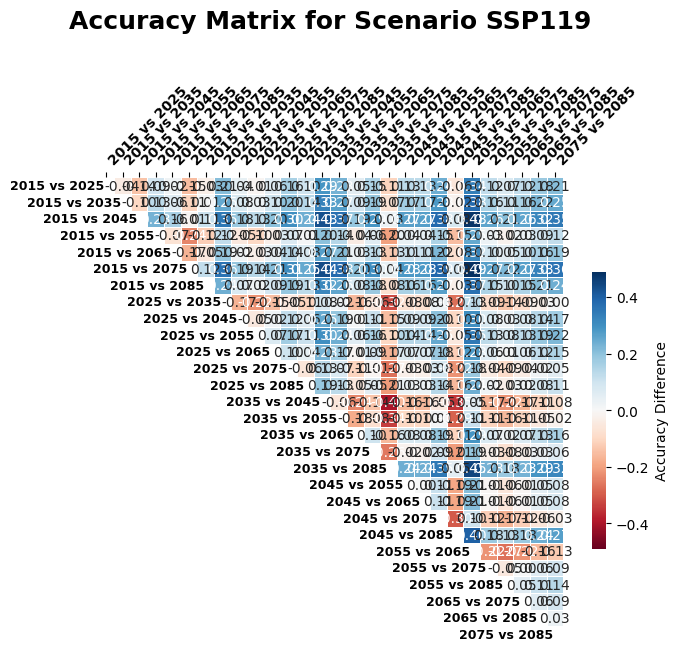

In [ ]:
def final_formatted_heatmap(df, scenario_id, prefix):
    # clean up labels 
    df.index = [str(i).replace(prefix, '').replace('_', ' vs ') for i in df.index]
    #if col headers are multi-levels
    if hasattr(df.columns, 'levels'):
        df.columns = [str(c[1]).replace(prefix, '').replace('_', ' vs ') for c in df.columns]
    else:
        df.columns = [str(c).replace(prefix, '').replace('_', ' vs ') for c in df.columns]
    #save clean labels to list for manual y axis placement
    labels = df.index.tolist()
    
    plt.figure(figsize=(7,7))
    
   # create boolean lower triangle filter 
    # k=0 hides the diagonal cells 
    mask = np.tril(np.ones_like(df, dtype=bool), k=0)

    # for symmetrical colorbar
    vmax = np.nanmax(np.abs(df.values))

    # 5. Plot the Heatmap
    # center=0 ensures white represents no difference in accuracy
    ax = sns.heatmap(df, 
                     mask=mask, 
                     cmap='RdBu', 
                     center=0, # ensure that 0 diff is white
                     vmin=-vmax, 
                     vmax=vmax,
                     annot=True, # add accuracy lables 
                     fmt=".2f",
                     square=True,
                     linewidths=.5, 
                     cbar_kws={"shrink": .5, "label": "Accuracy Difference"}) # make cbar smallr and add label

    # moving x axis tick marks and labels to top 
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    
    # styling x axis labels 
    plt.xticks(rotation=45, ha='left', fontweight='bold', fontsize=10)
 



    for i in range(len(labels)):
        # put text in empty space in the lower triangle mask 
        ax.text(i + 0.4, i + 0.5, labels[i], 
                ha='right', va='center', rotation=0, 
                fontsize=9, fontweight='bold')

    # add title 
    plt.title(f"Accuracy Matrix for Scenario {scenario_id.upper()}", fontsize=18, fontweight='bold', pad=40)
    # remove set x and y axis labels 
    plt.xlabel("")
    ax.set_yticks([])
    plt.ylabel("")
    
    plt.tight_layout()
    plt.show()

# Execution example:
final_formatted_heatmap(df_119, scenario_id="ssp119", prefix="ssp119_")

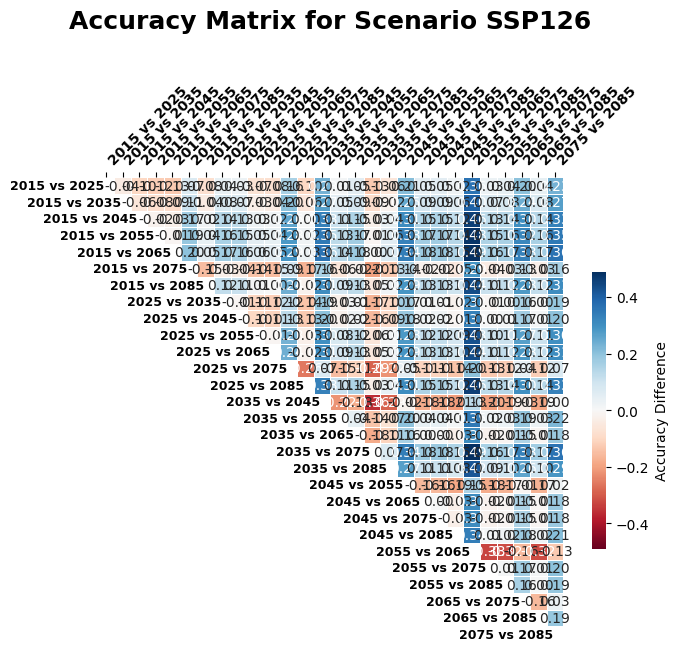

In [ ]:
final_formatted_heatmap(df_126, scenario_id="ssp126", prefix="ssp126_")

Test